In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

import plotly.express as px

import scanpy as sc
import scipy.sparse as sp

In [ ]:
movies42_df = pd.read_pickle("results_42movies.pkl")

# Remove columns with fewer than 10 non-zero entries
matrix = movies42_df.loc[:, movies42_df.astype(bool).sum(axis=0) >= 10]

# Remove rows with fewer than 10 non-zero entries
matrix = matrix.loc[matrix.astype(bool).sum(axis=1) >= 10, :]

print(matrix.shape)

In [15]:
users_df = pd.read_pickle('users_df.pkl')

# Remove columns with fewer than 10 non-zero entries
matrix = users_df.loc[:, users_df.astype(bool).sum(axis=0) >= 10]

# Remove rows with fewer than 10 non-zero entries
matrix = matrix.loc[matrix.astype(bool).sum(axis=1) >= 10, :]

print(matrix.shape)

(131, 5808)


# converting to scanpy data

In [27]:
def pandas_to_scanpy(df):
    X = sp.csr_matrix(df.sparse.to_coo())  # keeps it sparse

    # Create AnnData
    adata = sc.AnnData(X=X)
    adata.obs_names = df.index       # preserve row labels
    adata.var_names = df.columns     # preserve column names

    return adata

def pca(sc_data, n_pc = 20):
    sc.tl.pca(sc_data, n_comps=n_pc, svd_solver='arpack') 

    pca_result = sc_data.obsm['X_pca']  # shape = (n_rows, n_comps)

    n = 5
    pca_df = pd.DataFrame(
        sc_data.obsm['X_pca'][:, :n],
        index=sc_data.obs_names,
        columns=[f'PC{n}' for n in range(1,n+1)]
    )

    return pca_df

def plot_pca_variance(sc_data):
    explained_variance_ratio = sc_data.uns['pca']['variance_ratio']

    # Scree plot
    plt.figure(figsize=(8,5))
    plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('PCA Explained Variance')
    plt.show()

def plot_pca(pca_df, comps = [1, 2]):
    comp_names = [f'PC{n}' for n in comps]

    fig = px.scatter(
        x=pca_df[comp_names[0]],
        y=pca_df[comp_names[1]],
        hover_name=pca_df.index,   # show row labels on hover
        labels={"x": comp_names[0], "y": comp_names[1]}
    )

    fig.update_layout(
        width=800,   # pixels
        height=600,  # pixels
    )
    fig.show()

def plot_sample(df, id):
    current_df = df.loc[id]
    current_df = current_df[current_df != 0].sparse.to_dense()
    n_movies = len(current_df)

    bin_edges = np.arange(0.5, 11.5, 1)

    plt.figure(figsize=(3, 2))
    plt.hist(current_df.values.flatten(), bins=bin_edges, color='skyblue', edgecolor='black')
    plt.xticks(np.arange(1, 11))
    plt.title(f'{id} - {n_movies} ratings')
    plt.xlim([0.5,10.5])
    plt.show()

In [17]:
sc_data_users = pandas_to_scanpy(matrix)

pca_df_users = pca(sc_data_users)

plot_pca(pca_df_users, (1,2))

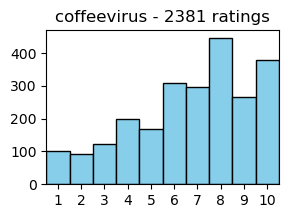

In [22]:
plot_sample(matrix, 'coffeevirus')

In [25]:
matrix_T = matrix.T

sc_data_movies = pandas_to_scanpy(matrix_T)

pca_df_movies = pca(sc_data_movies)

plot_pca(pca_df_movies, (1,2))

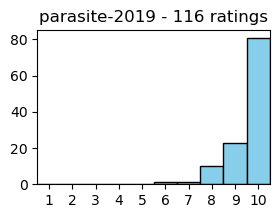

In [29]:
plot_sample(matrix_T, 'parasite-2019')

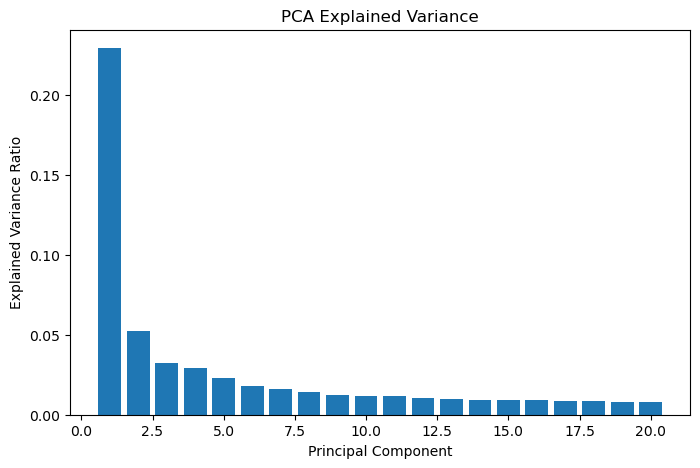

In [30]:
plot_pca_variance(sc_data_movies)

In [ ]:
# 2️⃣ Compute the neighborhood graph
sc.pp.neighbors(sc_data_movies, n_neighbors=15, n_pcs=20)

# 3️⃣ Run UMAP
sc.tl.umap(sc_data_movies)

# adata.obsm['X_umap'] contains the UMAP coordinates
umap_df = pd.DataFrame(
    sc_data_movies.obsm['X_umap'],
    index=sc_data_movies.obs_names,        # preserve row labels
    columns=['UMAP1', 'UMAP2']    # name the dimensions
)



                                         UMAP1     UMAP2
nobody-2                             -6.800650  1.332011
weapons-2025                         -0.284201  1.230309
the-naked-gun                        -3.226871  1.799079
i-know-what-you-did-last-summer-2025 -8.310596  2.374315
m3gan-20                             -3.532712  1.151358


In [33]:
fig = px.scatter(
    x=umap_df['UMAP1'],
    y=umap_df['UMAP2'],
    hover_name=umap_df.index,   # show row labels on hover
    labels={"x": 'UMAP1', "y": 'UMAP2'}
)

fig.update_layout(
    width=800,   # pixels
    height=600,  # pixels
)
fig.show()

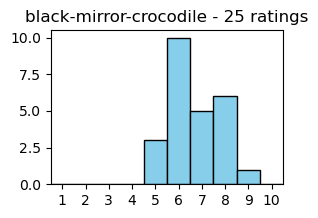

In [34]:
plot_sample(matrix_T, 'black-mirror-crocodile')